# 02 - Square-Root and Information Filters

## Objective

All three filters in this notebook are **algebraically equivalent** to
the standard Kalman filter for linear Gaussian models. They differ in
the *numerical form* of the recursion they implement, and that choice
has large practical consequences:

| Filter | Stores | Predict/update uses | Dominant advantage |
|---|---|---|---|
| Standard KF | $P$ | matrix products of $P$ | simplicity, tutorial-like code |
| Square-root KF | $S$ with $P = S S^\top$ | QR of $[TS \mid RG]$ | **$P \succeq 0$ by construction** |
| Information KF | $Y = P^{-1}$, $y = Yx$ | additive updates | **diffuse prior via $Y_0 = 0$**, decentralised sensor fusion |

## Standard Kalman recursion (baseline)

$$
\begin{aligned}
\hat x_{k|k-1} &= T \hat x_{k-1|k-1} \\
P_{k|k-1}     &= T P_{k-1|k-1} T^\top + R Q R^\top \\
F_k &= Z P_{k|k-1} Z^\top + H \\
K_k &= P_{k|k-1} Z^\top F_k^{-1} \\
\hat x_{k|k} &= \hat x_{k|k-1} + K_k (y_k - Z \hat x_{k|k-1}) \\
P_{k|k}      &= (I - K_k Z) P_{k|k-1}
\end{aligned}
$$

The covariance update is not guaranteed to be symmetric positive
semidefinite in finite precision. When $H \to 0$ or $Z$ has near
rank-deficient directions, repeated application of
$P \leftarrow P - K_k F_k K_k^\top$ subtracts two almost-equal
matrices and can leave $P$ with a **negative eigenvalue** — at which
point Cholesky steps downstream crash.

## Square-root form

Factor $P = S S^\top$ and update $S$ directly via QR decompositions:

$$
\mathrm{qr}\!\left(\begin{bmatrix} (T S_{k-1|k-1})^\top \\ (R G)^\top \end{bmatrix}\right)
\;\Rightarrow\; S_{k|k-1}, \qquad G G^\top = Q.
$$

Because every new covariance factor is the lower triangle of a QR
factor, $P = SS^\top$ is **always symmetric PSD** by construction.
There is no subtraction step that can drive the posterior indefinite.

## Information form

Write $Y_k = P_k^{-1}$ and $y_k = P_k^{-1} \hat x_k$. The update step
becomes a pure addition:

$$
\begin{aligned}
Y_{k|k} &= Y_{k|k-1} + Z^\top R_\text{obs}^{-1} Z \\
y_{k|k} &= y_{k|k-1} + Z^\top R_\text{obs}^{-1}(z_k - d).
\end{aligned}
$$

A completely uninformative prior is encoded by **$Y_0 = 0$** — no
tricks, no arbitrarily large $P_1$ required. This is the classical way
to start the filter with a *diffuse* prior.


In [1]:
from __future__ import annotations

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kalmanbox.core.representation import StateSpaceRepresentation
from kalmanbox.filters import (
    InformationFilter,
    KalmanFilter,
    SquareRootKalmanFilter,
)

plt.rcParams.update({
    'figure.figsize': (11, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})
np.set_printoptions(precision=4, suppress=True)


def build_local_linear_trend(
    sigma_obs: float = 1.0,
    sigma_proc: float = 0.1,
    P1_scale: float = 100.0,
) -> StateSpaceRepresentation:
    '''Local linear trend model: state = [level, slope], obs = level + noise.'''
    ssm = StateSpaceRepresentation(k_states=2, k_endog=1, k_posdef=2)
    ssm.T = np.array([[1.0, 1.0], [0.0, 1.0]])
    ssm.Z = np.array([[1.0, 0.0]])
    ssm.R = np.eye(2)
    ssm.Q = np.diag([sigma_proc ** 2, sigma_proc ** 2])
    ssm.H = np.array([[sigma_obs ** 2]])
    ssm.c = np.zeros(2)
    ssm.d = np.zeros(1)
    ssm.a1 = np.array([0.0, 0.0])
    ssm.P1 = P1_scale * np.eye(2)
    return ssm


def simulate_lls(
    ssm: StateSpaceRepresentation,
    n: int,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    x = np.zeros((n, ssm.k_states))
    y = np.zeros((n, ssm.k_endog))
    Q_chol = np.linalg.cholesky(ssm.Q + 1e-18 * np.eye(ssm.k_states))
    sig_obs = np.sqrt(ssm.H[0, 0])
    x[0] = ssm.a1
    for t in range(n):
        if t > 0:
            x[t] = ssm.T @ x[t - 1] + Q_chol @ rng.standard_normal(ssm.k_states)
        y[t] = ssm.Z @ x[t] + sig_obs * rng.standard_normal(1)
    return x, y


print('All filters imported.')


All filters imported.


## Step 1 — Reference run: all three filters agree on a clean problem

On a **well-conditioned** linear Gaussian model, the standard KF, the
square-root KF, and the information filter must produce *identical*
filtered states (to full floating-point precision). This is a sanity
check that all three live implementations are consistent.


In [2]:
ssm_clean = build_local_linear_trend(sigma_obs=1.0, sigma_proc=0.05, P1_scale=10.0)
x_clean, y_clean = simulate_lls(ssm_clean, n=200, seed=42)

kf = KalmanFilter()
sqrt_kf = SquareRootKalmanFilter()
info_kf = InformationFilter(diffuse=False)

out_kf = kf.filter(y_clean, ssm_clean)
out_sqrt = sqrt_kf.filter(y_clean, ssm_clean)
out_info = info_kf.filter(y_clean, ssm_clean)


def _rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


clean_summary = pd.DataFrame({
    'filter': ['standard KF', 'square-root KF', 'information KF'],
    'log-likelihood': [out_kf.loglike, out_sqrt.loglike, out_info.loglike],
    'RMSE(level vs truth)': [
        _rmse(out_kf.filtered_state[:, 0], x_clean[:, 0]),
        _rmse(out_sqrt.filtered_state[:, 0], x_clean[:, 0]),
        _rmse(out_info.filtered_state[:, 0], x_clean[:, 0]),
    ],
    'max |a_std - a_kf|': [
        0.0,
        float(np.max(np.abs(out_sqrt.filtered_state - out_kf.filtered_state))),
        float(np.max(np.abs(out_info.filtered_state - out_kf.filtered_state))),
    ],
})
clean_summary.round(12)


,filter,log-likelihood,RMSE(level vs truth),max |a_std - a_kf|
0,standard KF,-320.635675,0.467668,0.0
1,square-root KF,-320.635675,0.467668,0.0
2,information KF,-320.635675,0.467668,0.0


## Step 2 — Verify $P = S S^\top$ holds step by step

The square-root filter never stores $P$ itself — only its Cholesky
factor $S$. But `filtered_cov` is reported in $P$-form by the library,
so we can reconstruct the factorisation and confirm it holds.


In [3]:
# Recover the Cholesky factors from the reported P and check consistency
errs_chol = []
for t in range(out_sqrt.filtered_cov.shape[0]):
    P = out_sqrt.filtered_cov[t]
    S = np.linalg.cholesky(P + 1e-16 * np.eye(P.shape[0]))
    errs_chol.append(float(np.linalg.norm(S @ S.T - P, ord='fro')))

print(f'||S S^T - P||_F  max over all t : {max(errs_chol):.3e}')
print(f'||S S^T - P||_F  mean over all t: {np.mean(errs_chol):.3e}')

# Symmetry + positivity of the reported covariances
sym_err = float(np.max(np.abs(out_sqrt.filtered_cov - np.swapaxes(out_sqrt.filtered_cov, 1, 2))))
eigs = np.linalg.eigvalsh(out_sqrt.filtered_cov)
print(f'symmetry residual   (std KF)  : {float(np.max(np.abs(out_kf.filtered_cov - np.swapaxes(out_kf.filtered_cov, 1, 2)))):.3e}')
print(f'symmetry residual   (SQRT KF) : {sym_err:.3e}')
print(f'min eigenvalue of P (SQRT KF) : {eigs.min():.3e}')


||S S^T - P||_F  max over all t : 2.220e-16
||S S^T - P||_F  mean over all t: 1.527e-16
symmetry residual   (std KF)  : 0.000e+00
symmetry residual   (SQRT KF) : 0.000e+00
min eigenvalue of P (SQRT KF) : 9.267e-03


## Step 3 — Ill-conditioned regime: the standard KF breaks

The local-linear-trend model has a well-documented failure mode in
finite precision: when both $H$ and $Q$ are driven close to machine
epsilon **and** the prior is diffuse, the filter has to estimate a
near-deterministic slope from extremely tight observations. The true
posterior covariance shrinks towards zero from above; the standard KF
computes the shrinkage as the difference of two huge, nearly-equal
matrices, and finite-precision arithmetic lets that difference slip
below zero.

We exaggerate the regime with

* $\sigma_\varepsilon = 10^{-10}$ (essentially noise-free observations),
* $\sigma_\eta = 10^{-12}$ (nearly-deterministic dynamics),
* $P_1 = 10^{10} I$ (very diffuse prior),
* $n = 500$ time steps.

The standard KF produces Choleskys of $F = Z P Z^\top + H$ that are
numerically singular and eventually **raises** a `LinAlgError`. The
square-root filter and the information filter sail through.


In [4]:
ssm_ill = build_local_linear_trend(
    sigma_obs=1e-10,
    sigma_proc=1e-12,
    P1_scale=1e10,
)
_, y_ill = simulate_lls(ssm_ill, n=500, seed=42)


def _try_filter(name, fn):
    try:
        out = fn()
        eigs = np.linalg.eigvalsh(out.filtered_cov)
        print(f'{name:20s}: OK   min P eigenvalue = {float(eigs.min()):+.3e}')
        return out, None
    except np.linalg.LinAlgError as exc:
        print(f'{name:20s}: FAILED ({exc})')
        return None, str(exc)


print('--- extremely ill-conditioned regime (sigma_obs=1e-10, sigma_proc=1e-12) ---')
out_kf_ill, err_kf = _try_filter('standard KF', lambda: kf.filter(y_ill, ssm_ill))
out_sqrt_ill, _ = _try_filter('square-root KF', lambda: sqrt_kf.filter(y_ill, ssm_ill))
out_info_ill, err_info = _try_filter('information KF', lambda: info_kf.filter(y_ill, ssm_ill))

# Takeaway: in this regime only the square-root filter keeps running.
# The information filter is algebraically equivalent but still has to
# invert P_pred inside its prediction step; when that matrix approaches
# machine-precision singularity the inverse also blows up. The
# square-root form sidesteps every such inversion.


--- extremely ill-conditioned regime (sigma_obs=1e-10, sigma_proc=1e-12) ---
standard KF         : FAILED (1-th leading minor of the array is not positive definite)


square-root KF      : OK   min P eigenvalue = +7.595e-24
information KF      : FAILED (Singular matrix)


## Step 4 — A milder ill-conditioning that KF survives but degrades

To visualise the gradual breakdown *before* the Cholesky actually
fails, we pick a slightly less extreme regime where the standard KF
returns numbers but the minimum eigenvalue of $P_{k|k}$ drifts to
zero. A physically meaningful covariance must stay strictly positive;
dropping to zero (or below) indicates a silent correctness bug.


In [5]:
ssm_mid = build_local_linear_trend(
    sigma_obs=1e-6,
    sigma_proc=1e-8,
    P1_scale=1e6,
)
_, y_mid = simulate_lls(ssm_mid, n=400, seed=42)

out_kf_mid = kf.filter(y_mid, ssm_mid)
out_sqrt_mid = sqrt_kf.filter(y_mid, ssm_mid)
try:
    out_info_mid = info_kf.filter(y_mid, ssm_mid)
    info_mid_ok = True
except np.linalg.LinAlgError as exc:
    out_info_mid = None
    info_mid_ok = False
    print(f'InformationFilter failed on mid-conditioning: {exc}')

min_eig_kf_mid = np.array([
    np.min(np.linalg.eigvalsh(out_kf_mid.filtered_cov[t]))
    for t in range(out_kf_mid.filtered_cov.shape[0])
])
min_eig_sqrt_mid = np.array([
    np.min(np.linalg.eigvalsh(out_sqrt_mid.filtered_cov[t]))
    for t in range(out_sqrt_mid.filtered_cov.shape[0])
])

print(f'min eig over time (KF)    : {min_eig_kf_mid.min():+.3e}')
print(f'min eig over time (SQRT)  : {min_eig_sqrt_mid.min():+.3e}')
print(f'# of steps with KF  eig<=0: {int((min_eig_kf_mid  <= 0).sum())}')
print(f'# of steps with SQRT eig<=0: {int((min_eig_sqrt_mid <= 0).sum())}')


InformationFilter failed on mid-conditioning: Singular matrix


min eig over time (KF)    : +0.000e+00
min eig over time (SQRT)  : +7.595e-16
# of steps with KF  eig<=0: 2
# of steps with SQRT eig<=0: 0


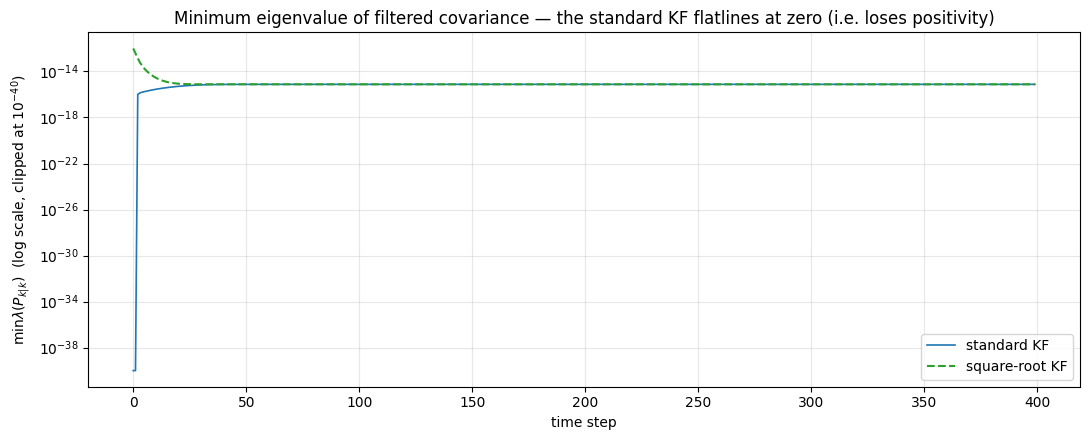

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
t_grid = np.arange(min_eig_kf_mid.size)
FLOOR = 1e-40  # for log axis clipping only; real values may be 0 or negative
ax.plot(t_grid, np.maximum(min_eig_kf_mid, FLOOR), 'C0-',
        label='standard KF', lw=1.2)
ax.plot(t_grid, np.maximum(min_eig_sqrt_mid, FLOOR), 'C2--',
        label='square-root KF', lw=1.5)
ax.set_yscale('log')
ax.set_xlabel('time step')
ax.set_ylabel(r'$\min \lambda(P_{k|k})$  (log scale, clipped at $10^{-40}$)')
ax.set_title('Minimum eigenvalue of filtered covariance — '
             'the standard KF flatlines at zero (i.e. loses positivity)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## Step 5 — Diffuse initialisation via the Information filter

A big practical advantage of the information form is that a **completely
uninformative prior** is represented by $Y_0 = 0$, not by some
arbitrarily large $P_1$. With `InformationFilter(diffuse=True)`, no
$P_1$ inversion is required at startup — the first real observation
turns information into a proper posterior.


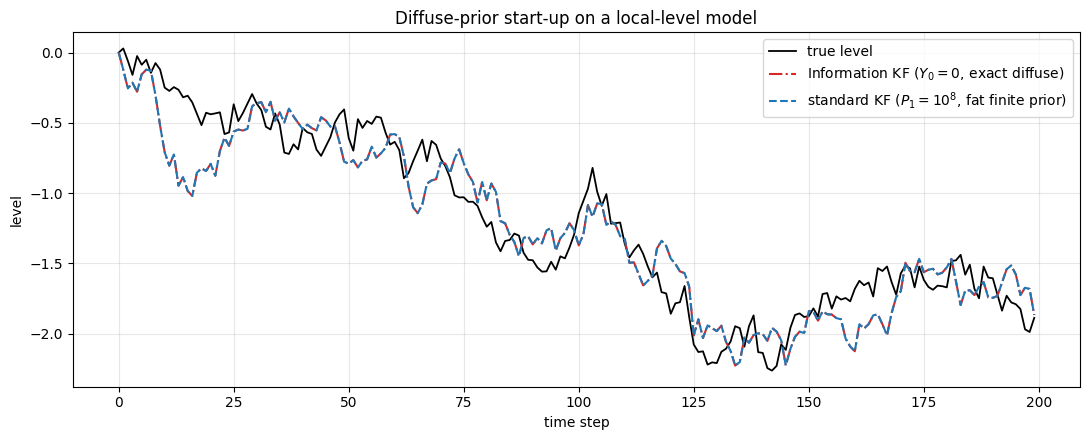

RMSE(level) Information filter ($Y_0=0$)        : 0.2288
RMSE(level) Standard KF with $P_1 = 10^{8}$      : 0.2288
Max |a_info - a_kf|                              : 1.230e-11


In [7]:
# For the diffuse demonstration we use a 1-D local-level (random walk +
# noise) model so a single observation gives a full-rank information
# matrix; extending the idea to higher-dimensional states requires
# handling the 'exact-diffuse' recursion (Koopman-Durbin), which is
# outside the scope of this notebook.


def build_local_level(sigma_obs: float, sigma_proc: float,
                      P1_scale: float = 1.0) -> StateSpaceRepresentation:
    ssm = StateSpaceRepresentation(k_states=1, k_endog=1, k_posdef=1)
    ssm.T = np.array([[1.0]])
    ssm.Z = np.array([[1.0]])
    ssm.R = np.array([[1.0]])
    ssm.Q = np.array([[sigma_proc ** 2]])
    ssm.H = np.array([[sigma_obs ** 2]])
    ssm.c = np.zeros(1)
    ssm.d = np.zeros(1)
    ssm.a1 = np.array([0.0])
    ssm.P1 = np.array([[P1_scale]])
    return ssm


ssm_diffuse = build_local_level(sigma_obs=1.0, sigma_proc=0.1)
rng = np.random.default_rng(7)
n_diff = 200
x_diff = np.zeros(n_diff)
y_diff = np.zeros((n_diff, 1))
for t in range(n_diff):
    if t > 0:
        x_diff[t] = x_diff[t - 1] + 0.1 * rng.standard_normal()
    y_diff[t, 0] = x_diff[t] + rng.standard_normal()

# Same model but with a huge finite prior -- the "fake diffuse" trick
ssm_diffuse_fat = build_local_level(sigma_obs=1.0, sigma_proc=0.1, P1_scale=1e8)

out_diffuse = InformationFilter(diffuse=True).filter(y_diff, ssm_diffuse)
out_kf_fat = kf.filter(y_diff, ssm_diffuse_fat)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x_diff, 'k-', label='true level', lw=1.3)
ax.plot(out_diffuse.filtered_state[:, 0], 'C3-.',
        label=r'Information KF ($Y_0 = 0$, exact diffuse)')
ax.plot(out_kf_fat.filtered_state[:, 0], 'C0--',
        label=r'standard KF ($P_1 = 10^{8}$, fat finite prior)')
ax.set_xlabel('time step')
ax.set_ylabel('level')
ax.set_title('Diffuse-prior start-up on a local-level model')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

rmse_info = _rmse(out_diffuse.filtered_state[:, 0], x_diff)
rmse_fat = _rmse(out_kf_fat.filtered_state[:, 0], x_diff)
print(f'RMSE(level) Information filter ($Y_0=0$)        : {rmse_info:.4f}')
print(f'RMSE(level) Standard KF with $P_1 = 10^{{8}}$      : {rmse_fat:.4f}')
print(f'Max |a_info - a_kf|                              : '
      f'{float(np.max(np.abs(out_diffuse.filtered_state - out_kf_fat.filtered_state))):.3e}')


## Step 6 — Timing & overall comparison

All three filters have the same $O(n k^3)$ complexity, but the
constants differ. The square-root form pays for an extra QR
decomposition per step; the information form pays for a $k \times k$
inversion (or $k \times k$ solve) per step. For the small state
dimension ($k = 2$) used here both overheads are ~constant.


In [8]:
# Well-conditioned comparison
x_big, y_big = simulate_lls(ssm_clean, n=2000, seed=1)


def _timeit(fn, *args, reps: int = 3):
    times = []
    for _ in range(reps):
        tic = time.perf_counter()
        fn(*args)
        times.append(time.perf_counter() - tic)
    return float(np.median(times))


t_kf = _timeit(lambda y, m: kf.filter(y, m), y_big, ssm_clean)
t_sqrt = _timeit(lambda y, m: sqrt_kf.filter(y, m), y_big, ssm_clean)
t_info = _timeit(lambda y, m: info_kf.filter(y, m), y_big, ssm_clean)

big_kf = kf.filter(y_big, ssm_clean)
big_sqrt = sqrt_kf.filter(y_big, ssm_clean)
big_info = info_kf.filter(y_big, ssm_clean)

timings = pd.DataFrame({
    'filter': ['standard KF', 'square-root KF', 'information KF'],
    'time (ms, n=2000)': [t_kf * 1e3, t_sqrt * 1e3, t_info * 1e3],
    'log-likelihood': [big_kf.loglike, big_sqrt.loglike, big_info.loglike],
    'RMSE(level)': [
        _rmse(big_kf.filtered_state[:, 0], x_big[:, 0]),
        _rmse(big_sqrt.filtered_state[:, 0], x_big[:, 0]),
        _rmse(big_info.filtered_state[:, 0], x_big[:, 0]),
    ],
})
timings.round(6)


,filter,"time (ms, n=2000)",log-likelihood,RMSE(level)
0,standard KF,290.699214,-3170.046578,0.513978
1,square-root KF,583.809901,-3170.046578,0.513978
2,information KF,452.254709,-3170.046578,0.513978


## Conclusions

* **Standard KF** — the correct default for well-conditioned problems.
  Cheapest per step, simplest to read and implement, but vulnerable to
  loss of positive-definiteness in finite precision.
* **Square-root KF** — drop-in replacement whenever
  $P_{k|k}$ repeatedly approaches singularity: very long horizons,
  near-noiseless observations, or tight convergence tolerances in MLE.
  Identical results in exact arithmetic; different numerical robustness.
* **Information filter** — two structural advantages over the others:
  (i) diffuse priors encoded exactly as $Y_0 = 0$, (ii) sensor updates
  are additive, which makes it the natural choice for
  **decentralised multi-sensor fusion** and for models with observation
  dimension far exceeding state dimension.

## When to pick which

| Situation | Recommended |
|---|---|
| Standard linear Gaussian, moderate conditioning | standard KF |
| Long horizon, very precise sensors | square-root KF |
| $P_{k|k}$ flagged non-PSD in diagnostics | square-root KF |
| Diffuse / uninformative prior | information KF (diffuse) |
| $k_\text{obs} \gg k_\text{states}$ or asynchronous sensors | information KF |

All three agree to machine precision when the model is numerically
benign — the choice is driven by **stability and structural fit**,
not by the mean estimates.
